# QLoRA Fine-Tune — HW5 M5 Extension (assignment §5.7)

**Purpose:** Run the QLoRA fine-tune extension per `docs/PRD_qlora.md` (DP-7, approved 2026-07-01). NF4-quantized TinyLlama-1.1B + LoRA adapters fine-tuned on 500 Alpaca examples.

**Runtime requirement:** T4 GPU. Go to **Runtime → Change runtime type → T4 GPU** before running.

**Expected wall time:** ~15-25 min of training + ~5-10 min of setup and inference = **~20-35 min total**.

**Downloads to save back to the repo after this notebook finishes:**

| File | Repo destination |
|---|---|
| `qlora_tinyllama-1.1b_<ts>.json` | `results/` |
| `qlora_loss_<ts>.csv` | `results/` |
| `qlora_loss.png` | `figures/` |
| `qlora_adapter_tinyllama-1.1b_<ts>.zip` | `results/` |

See `docs/PRD_qlora.md` §5.4 for the cell-by-cell contract.

## Cell 1 — Install dependencies

~1-2 min. `peft bitsandbytes accelerate transformers datasets` are the QLoRA stack per L08 §5.1.

In [1]:
!pip install -q -U peft bitsandbytes accelerate transformers datasets matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.7 MB/s eta 0:00:00


## Cell 2 — Config

Values pinned to `docs/PRD_qlora.md` §4.1 defaults (approved 2026-07-01). Edit ONLY here if you want to tweak the run — everything downstream reads this dict.

In [2]:
CONFIG = {
    "base_model_id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "base_model_label": "tinyllama-1.1b",
    "dataset_hf_id": "yahma/alpaca-cleaned",
    "subset_size": 500,
    "lora": {
        "rank": 8,
        "alpha": 16,
        "dropout": 0.05,
        "target_modules": ["q_proj", "v_proj"],
    },
    "training": {
        "epochs": 1,
        "max_steps": 200,
        "batch_size": 1,
        "gradient_accumulation_steps": 8,
        "learning_rate": 2e-4,
        "warmup_steps": 20,
        "gradient_checkpointing": True,
        "paged_optimizer": True,
    },
    "measurement": {
        "eval_prompt": "Explain quantum entanglement in one paragraph.",
        "max_new_tokens": 128,
    },
    "seed": 42,
    "venue": "colab_t4_16gb",
}
print("Config loaded. Base:", CONFIG["base_model_id"])

Config loaded. Base: TinyLlama/TinyLlama-1.1B-Chat-v1.0


## Cell 3 — Imports + reproducibility seeds

Fails FAST if CUDA is unavailable — that means you forgot to switch runtime to T4 GPU.

In [3]:
import os
import json
import time
import gc
import csv
import random
import shutil
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
    Trainer, TrainingArguments, TrainerCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA not available. Go to Runtime > Change runtime type > T4 GPU."
    )
torch.cuda.manual_seed_all(CONFIG["seed"])

print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print(f"Total VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

CUDA device: Tesla T4
Total VRAM:  15.64 GB


## Cell 4 — Load base model in NF4 (L08 §5.1)

`BitsAndBytesConfig` per QLoRA canonical recipe:
- `load_in_4bit=True` — weights stored in NF4.
- `bnb_4bit_compute_dtype=fp16` — matmul happens in fp16 via on-the-fly dequant.
- `bnb_4bit_quant_type="nf4"` — normal-float 4-bit (Dettmers et al.).
- `bnb_4bit_use_double_quant=True` — quantize the quantization constants themselves.

Records `nf4_load_vram_mb` — the empirical NF4 base-model footprint. Should be **~600-900 MB for TinyLlama-1.1B** vs ~2.2 GB in fp16.

In [4]:
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(CONFIG["base_model_id"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

torch.cuda.empty_cache(); gc.collect()
torch.cuda.reset_peak_memory_stats(0)

base = AutoModelForCausalLM.from_pretrained(
    CONFIG["base_model_id"],
    quantization_config=bnb,
    device_map="auto",
    torch_dtype=torch.float16,
)

nf4_load_vram_mb = torch.cuda.max_memory_allocated(0) / 1e6
print(f"NF4 base model loaded. VRAM peak (post-load): {nf4_load_vram_mb:.1f} MB")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

NF4 base model loaded. VRAM peak (post-load): 802.0 MB


## Cell 5 — Attach LoRA adapters (L08 §7.3)

`ΔW = BA` where `A ∈ R^(r×k)` and `B ∈ R^(d×r)`. With `r=8`, only ~0.1-0.3% of total parameters are trainable — the LoRA efficiency claim K8 depends on.

In [5]:
lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=CONFIG["lora"]["rank"],
    lora_alpha=CONFIG["lora"]["alpha"],
    lora_dropout=CONFIG["lora"]["dropout"],
    target_modules=CONFIG["lora"]["target_modules"],
    bias="none",
)
model = get_peft_model(base, lora_cfg)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
trainable_pct = 100.0 * trainable / total
print(f"Trainable params: {trainable:,} ({trainable_pct:.3f}% of {total:,} total)")

Trainable params: 1,126,400 (0.183% of 616,732,672 total)


## Cell 6 — Load + prepare dataset

Alpaca format: `{instruction, input, output}`. Tokenized to `max_length=512` — matches TinyLlama's context window.

In [6]:
raw = load_dataset(CONFIG["dataset_hf_id"], split=f"train[:{CONFIG['subset_size']}]")

def format_example(ex):
    ins = ex["instruction"]
    inp = (ex.get("input") or "").strip()
    out = ex["output"]
    if inp:
        text = (
            f"### Instruction:\n{ins}\n\n### Input:\n{inp}\n\n### Response:\n{out}"
        )
    else:
        text = f"### Instruction:\n{ins}\n\n### Response:\n{out}"
    return {"text": text}

formatted = raw.map(format_example, remove_columns=raw.column_names)

def tokenize(ex):
    return tokenizer(ex["text"], truncation=True, max_length=512, padding=False)

tokenized = formatted.map(tokenize, remove_columns=["text"])
tokenized.set_format("torch")
print(f"Dataset ready: {len(tokenized)} examples")

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

alpaca_data_cleaned.json:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset ready: 500 examples


## Cell 7 — Baseline inference (before training)

Records `output_before` on the fixed eval prompt + inference VRAM peak. The report's before/after comparison depends on this snapshot.

In [7]:
torch.cuda.empty_cache(); gc.collect()
torch.cuda.reset_peak_memory_stats(0)

def run_inference(m, prompt, max_new_tokens=128):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    m.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        out = m.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, pad_token_id=tokenizer.pad_token_id,
        )
    wall = time.perf_counter() - t0
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return text, wall

output_before, wall_inf_before = run_inference(
    model,
    CONFIG["measurement"]["eval_prompt"],
    CONFIG["measurement"]["max_new_tokens"],
)
inference_vram_before_mb = torch.cuda.max_memory_allocated(0) / 1e6
print(f"Inference VRAM peak (baseline): {inference_vram_before_mb:.1f} MB")
print(f"Baseline wall: {wall_inf_before:.2f}s")
print("\n--- OUTPUT BEFORE TRAINING ---")
print(output_before)

[transformers] Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Inference VRAM peak (baseline): 820.7 MB
Baseline wall: 1.80s

--- OUTPUT BEFORE TRAINING ---
Explain quantum entanglement in one paragraph.


## Cell 8 — Train (SFT via `Trainer`)

**Key knobs:**
- `optim="paged_adamw_8bit"` per PRD_qlora Q-QL-5 — Paged Optimizers keep optimizer state in CPU RAM, paged into VRAM only on the step (~50% VRAM saving).
- `gradient_checkpointing=True` — trades compute for memory by re-computing activations backward.
- `max_steps=200` per PRD_qlora Q-QL-3.
- `logging_steps=1` so we capture the full loss curve.

Expected wall: ~15-25 min on T4.

In [8]:
loss_history = []

class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kw):
        if logs is not None and "loss" in logs:
            loss_history.append({
                "step": state.global_step,
                "loss": logs["loss"],
                "learning_rate": logs.get("learning_rate", 0.0),
            })

def collate(batch):
    input_ids = [item["input_ids"] for item in batch]
    max_len = max(len(x) for x in input_ids)
    ids_pad = torch.full((len(batch), max_len), tokenizer.pad_token_id, dtype=torch.long)
    lbl_pad = torch.full((len(batch), max_len), -100, dtype=torch.long)
    attn = torch.zeros((len(batch), max_len), dtype=torch.long)
    for i, ids in enumerate(input_ids):
        n = len(ids)
        ids_pad[i, :n] = ids
        lbl_pad[i, :n] = ids
        attn[i, :n] = 1
    return {"input_ids": ids_pad, "labels": lbl_pad, "attention_mask": attn}

training_args = TrainingArguments(
    output_dir="/content/qlora_out",
    num_train_epochs=CONFIG["training"]["epochs"],
    max_steps=CONFIG["training"]["max_steps"],
    per_device_train_batch_size=CONFIG["training"]["batch_size"],
    gradient_accumulation_steps=CONFIG["training"]["gradient_accumulation_steps"],
    learning_rate=CONFIG["training"]["learning_rate"],
    warmup_steps=CONFIG["training"]["warmup_steps"],
    gradient_checkpointing=CONFIG["training"]["gradient_checkpointing"],
    optim="paged_adamw_8bit" if CONFIG["training"]["paged_optimizer"] else "adamw_torch",
    logging_steps=1,
    save_strategy="no",
    fp16=True,
    seed=CONFIG["seed"],
    report_to="none",
    remove_unused_columns=False,
)

torch.cuda.empty_cache(); gc.collect()
torch.cuda.reset_peak_memory_stats(0)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=collate,
    callbacks=[LossLogger()],
)

train_start = time.perf_counter()
trainer.train()
wall_train = time.perf_counter() - train_start
train_vram_peak_mb = torch.cuda.max_memory_allocated(0) / 1e6
final_train_loss = loss_history[-1]["loss"] if loss_history else float("nan")

print(f"\n=== Training complete ===")
print(f"Wall: {wall_train:.1f}s ({wall_train / 60:.1f} min)")
print(f"Train VRAM peak: {train_vram_peak_mb:.1f} MB")
print(f"Final loss: {final_train_loss:.4f}")
print(f"Steps logged: {len(loss_history)}")

Step,Training Loss
1,1.341859
2,1.351644
3,1.549830
4,1.274748
5,1.416859
6,1.489573
7,1.881143
8,1.588383
9,1.604485
10,1.924195



=== Training complete ===
Wall: 625.3s (10.4 min)
Train VRAM peak: 1060.6 MB
Final loss: 1.0241
Steps logged: 200


## Cell 9 — Post-training inference

Same eval prompt, adapter attached. Records `output_after` + post-train inference VRAM peak.

In [9]:
torch.cuda.empty_cache(); gc.collect()
torch.cuda.reset_peak_memory_stats(0)

output_after, wall_inf_after = run_inference(
    model,
    CONFIG["measurement"]["eval_prompt"],
    CONFIG["measurement"]["max_new_tokens"],
)
inference_vram_after_mb = torch.cuda.max_memory_allocated(0) / 1e6
print(f"Inference VRAM peak (after training): {inference_vram_after_mb:.1f} MB")
print(f"Post-train wall: {wall_inf_after:.2f}s")
print("\n--- OUTPUT AFTER TRAINING ---")
print(output_after)

[transformers] Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Inference VRAM peak (after training): 831.8 MB
Post-train wall: 9.47s

--- OUTPUT AFTER TRAINING ---
Explain quantum entanglement in one paragraph.
Explain quantum entanglement in one paragraph.
Quantum entanglement is a phenomenon where two particles are in a state of entanglement with each other, even if they are separated by a large distance. This means that the state of one particle can be affected by the state of the other particle, even if they are not directly connected. This phenomenon was first observed in 1935 by Einstein, Podolsky, and Rosen, and has since been studied extensively.
One of the most important applications of quantum entanglement is in quantum information processing. Entangled particles can be


## Cell 10 — Save artifacts + write manifest + plot loss curve

Produces the four files the notebook README asks you to download to the repo:
- `qlora_<label>_<ts>.json` (manifest — matches DP-7 §4.2 schema)
- `qlora_loss_<ts>.csv`
- `qlora_loss.png`
- `qlora_adapter_<label>_<ts>.zip` (LoRA weights, 10-50 MB)

Adapter zipped: /content/qlora_adapter_tinyllama-1.1b_20260701T195438Z.zip
Loss CSV saved: /content/qlora_loss_20260701T195438Z.csv


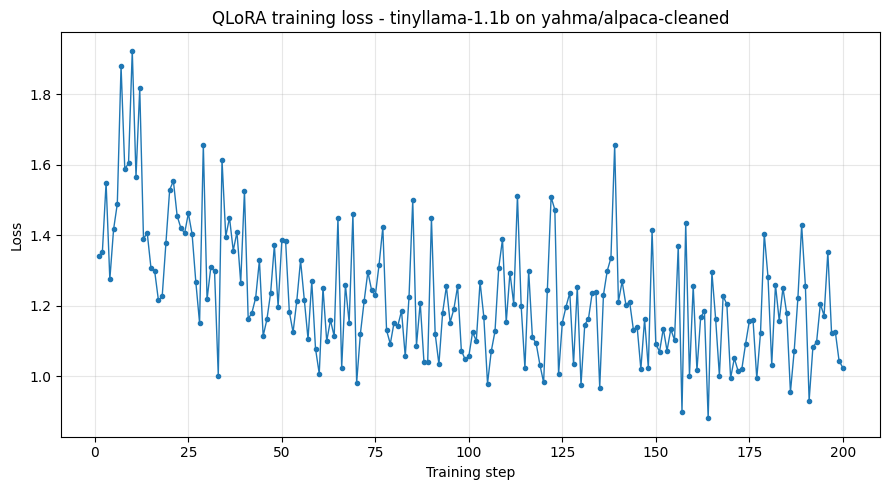

Loss plot saved: /content/qlora_loss.png
Manifest saved: /content/qlora_tinyllama-1.1b_20260701T195438Z.json

=== HEADLINE FINDINGS FOR REPORT ===
Trainable params:                1,126,400 (0.183% of total)
NF4 base VRAM (weights only):    802.0 MB
Inference VRAM peak:             820.7 MB
Train VRAM peak:                 1060.6 MB
VRAM ratio (train / inference):  1.29x
    (L08 §7.1 naive prediction:  3-5x; QLoRA flattens this substantially)
Final training loss:             1.0241
Total training steps:            200
Training wall:                   10.4 min


In [10]:
ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
label = CONFIG["base_model_label"]

adapter_dir = Path(f"/content/qlora_adapter_{label}_{ts}")
model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))
adapter_zip = shutil.make_archive(str(adapter_dir), "zip", root_dir=str(adapter_dir))
print(f"Adapter zipped: {adapter_zip}")

loss_csv = Path(f"/content/qlora_loss_{ts}.csv")
with loss_csv.open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["step", "loss", "learning_rate"])
    w.writeheader()
    for row in loss_history:
        w.writerow(row)
print(f"Loss CSV saved: {loss_csv}")

steps = [r["step"] for r in loss_history]
losses = [r["loss"] for r in loss_history]
plt.figure(figsize=(9, 5))
plt.plot(steps, losses, marker=".", linewidth=1)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title(f"QLoRA training loss - {label} on {CONFIG['dataset_hf_id']}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
loss_png = Path("/content/qlora_loss.png")
plt.savefig(str(loss_png), dpi=150, bbox_inches="tight")
plt.show()
print(f"Loss plot saved: {loss_png}")

vram_ratio = (
    train_vram_peak_mb / inference_vram_before_mb
    if inference_vram_before_mb > 0 else float("nan")
)

manifest = {
    "run_id": ts,
    "started_at": ts,
    "venue": CONFIG["venue"],
    "base_model_label": label,
    "base_model_id": CONFIG["base_model_id"],
    "dataset_hf_id": CONFIG["dataset_hf_id"],
    "dataset_subset_size": CONFIG["subset_size"],
    "lora": CONFIG["lora"],
    "training": CONFIG["training"],
    "measurement": CONFIG["measurement"],
    "trainable_params": int(trainable),
    "total_params": int(total),
    "trainable_pct": trainable_pct,
    "nf4_load_vram_mb": nf4_load_vram_mb,
    "train_vram_peak_mb": train_vram_peak_mb,
    "inference_vram_peak_mb_before": inference_vram_before_mb,
    "inference_vram_peak_mb_after": inference_vram_after_mb,
    "vram_ratio": vram_ratio,
    "final_train_loss": final_train_loss,
    "total_steps": len(loss_history),
    "wall_s_train": wall_train,
    "wall_s_inference_before": wall_inf_before,
    "wall_s_inference_after": wall_inf_after,
    "output_before": output_before,
    "output_after": output_after,
    "adapter_zip": adapter_zip,
    "loss_curve_csv": str(loss_csv),
    "loss_plot_png": str(loss_png),
    "cuda_device": torch.cuda.get_device_name(0),
    "cuda_total_vram_gb": torch.cuda.get_device_properties(0).total_memory / 1e9,
    "seed": CONFIG["seed"],
}

manifest_path = Path(f"/content/qlora_{label}_{ts}.json")
manifest_path.write_text(json.dumps(manifest, indent=2))
print(f"Manifest saved: {manifest_path}")

print("\n=== HEADLINE FINDINGS FOR REPORT ===")
print(f"Trainable params:                {trainable:,} ({trainable_pct:.3f}% of total)")
print(f"NF4 base VRAM (weights only):    {nf4_load_vram_mb:.1f} MB")
print(f"Inference VRAM peak:             {inference_vram_before_mb:.1f} MB")
print(f"Train VRAM peak:                 {train_vram_peak_mb:.1f} MB")
print(f"VRAM ratio (train / inference):  {vram_ratio:.2f}x")
print(f"    (L08 §7.1 naive prediction:  3-5x; QLoRA flattens this substantially)")
print(f"Final training loss:             {final_train_loss:.4f}")
print(f"Total training steps:            {len(loss_history)}")
print(f"Training wall:                   {wall_train / 60:.1f} min")

## Cell 11 — Download files to your local repo

Run this cell to auto-download the 4 output files via the browser. Then in your local repo:

```
mkdir -p results figures
mv ~/Downloads/qlora_tinyllama-1.1b_*.json  results/
mv ~/Downloads/qlora_loss_*.csv             results/
mv ~/Downloads/qlora_adapter_tinyllama-1.1b_*.zip  results/
mv ~/Downloads/qlora_loss.png               figures/
```

Then tell Claude "QLoRA files committed" — Claude will add the §QLoRA section to README.md.

In [11]:
try:
    from google.colab import files
    files.download(str(manifest_path))
    files.download(str(loss_csv))
    files.download(str(loss_png))
    files.download(adapter_zip)
    print("Downloads triggered. Check your Downloads folder.")
except ImportError:
    print("Not in Colab — files remain at /content/. Copy them manually.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered. Check your Downloads folder.
